<h1 align="center">Visualización de Datos con Python </h1>

# U5.01. Visualización con pandas y Matplotlib

**¿POR QUÉ VISUALIZAR DATOS?**

- **Las visualizaciones aceleran la comprensión:** permiten detectar patrones, outliers y tendencias más rápido que leyendo una tabla.

- **Mejoran el recuerdo en muchos casos:** las imágenes y gráficos suelen ser más fáciles de recordar que texto puro (picture superiority effect), especialmente si son claros y relevantes. 

- **Una buena visualización “comprime” información:** comunica una idea compleja con menos esfuerzo cognitivo que una explicación larga (si está bien diseñada).

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
df = pd.read_csv('u5-datos-ventas.csv')

df.head()
df

,id_venta,fecha,producto,categoria,cantidad,precio_unitario,cliente,region,edad_cliente,ingresos_anuales
0,210,2025-01-01,Monitor LG,Electrónica,1,369.86,Diego López,Sur,56,104427.78
1,195,2025-01-03,Mouse Inalámbrico,Accesorios,3,51.35,Miguel González,Sur,33,56885.82
2,253,2025-01-05,Auriculares Logitech,Accesorios,3,92.83,Carlos Martínez,Sur,44,84686.67
3,485,2025-01-07,Webcam HD,Accesorios,1,69.59,Valentina García,Este,20,39543.00
4,194,2025-01-07,Webcam Full HD,Accesorios,3,141.23,Ana Sánchez,Oeste,25,55351.72
...,...,...,...,...,...,...,...,...,...,...
495,207,2025-12-27,Mouse Inalámbrico,Accesorios,2,37.95,Juan Rodríguez,Oeste,27,67607.60
496,142,2025-12-28,Mouse Inalámbrico,Accesorios,1,48.81,Laura Rodríguez,Este,50,101175.92
497,313,2025-12-29,Webcam HD,Accesorios,2,95.31,Sofía Fernández,Norte,47,83134.93
498,279,2025-12-30,Mouse Inalámbrico,Accesorios,1,42.32,Pedro López,Norte,23,43309.77


## Gráficos de Comparación

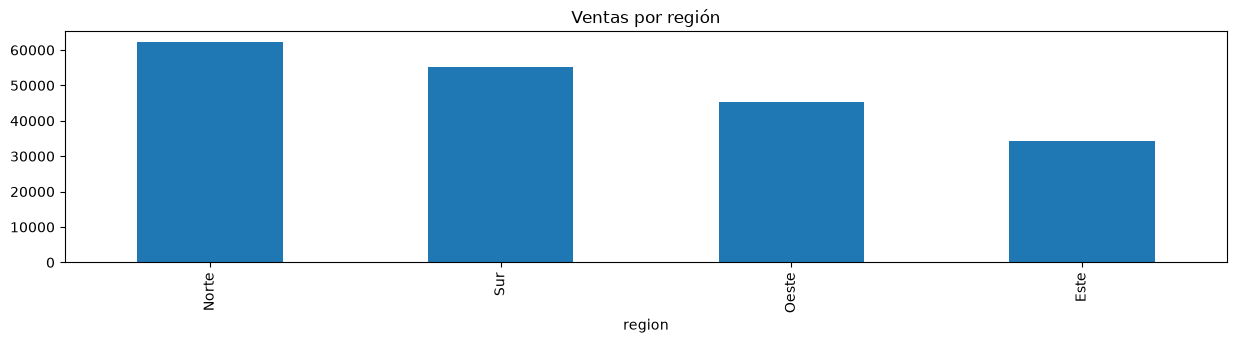

In [3]:
#Gráfico de barras: Comparación de cantidad de ventas por región
ventas_cat_desc = df.groupby('region')['precio_unitario'].sum().sort_values(ascending=False)
ventas_cat_desc.plot(kind='bar', figsize=(15, 3))
plt.title('Ventas por región')
plt.show()

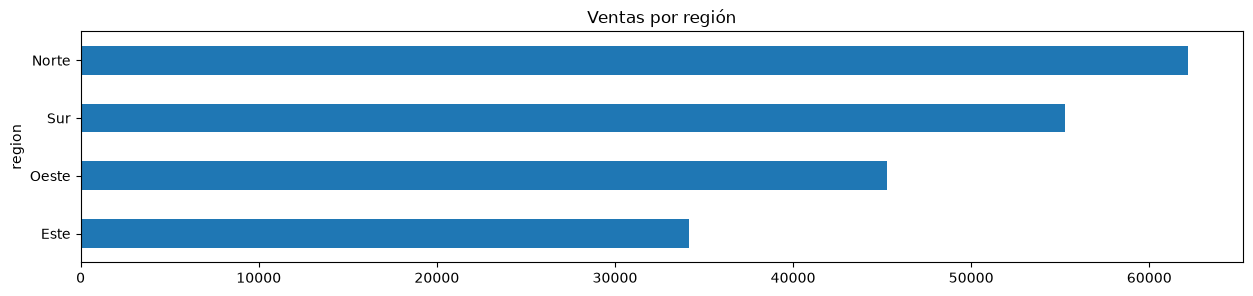

In [4]:
ventas_cat_desc = df.groupby('region')['precio_unitario'].sum().sort_values()
ventas_cat_desc.plot(kind='barh', figsize=(15, 3), title='Ventas por región')
plt.show()

##	Gráficos de tendencia y proporción

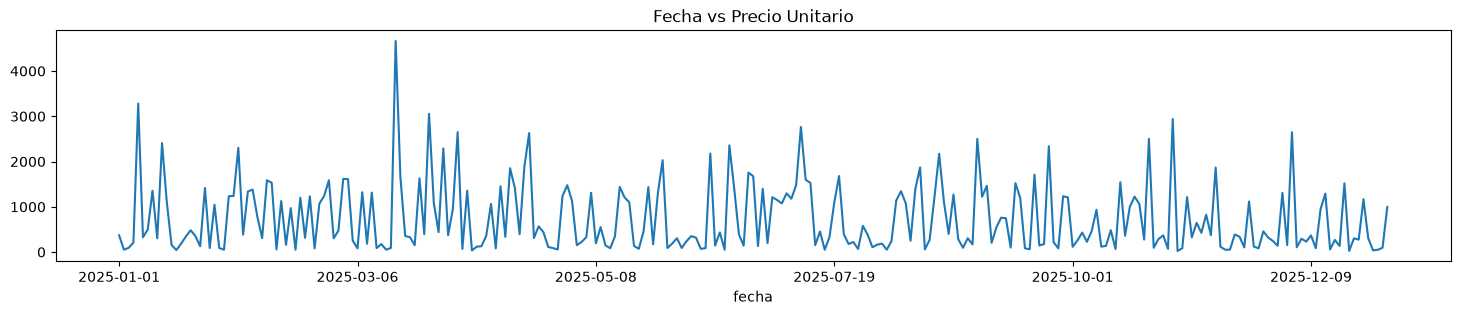

In [5]:
# Gráfico de línea: Evolución de ventas a lo largo del tiempo
ventas_tiempo = df.groupby('fecha')['precio_unitario'].sum()
ventas_tiempo.plot(kind='line', figsize=(18, 3), title='Fecha vs Precio Unitario')
plt.show()

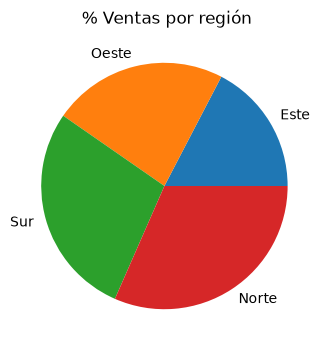

In [6]:
# Gtráfico de proporción: Distribución de ventas por región
ventas_cat_asc = df.groupby('region')['precio_unitario'].sum().sort_values(ascending=True)
ventas_cat_asc.plot(kind='pie', figsize=(4, 4),title=' % Ventas por región') 
plt.show()

##	Gráficos de relación y distribución

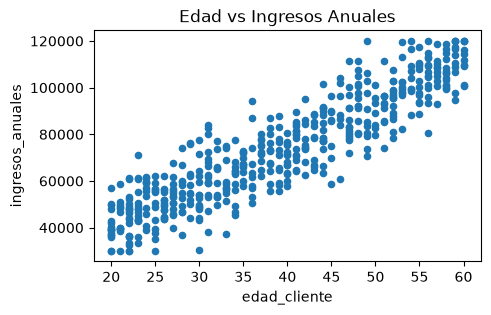

In [7]:
# Gráfico de dispersión: Relación entre edad del cliente e ingresos
df.plot(kind='scatter', x='edad_cliente', y='ingresos_anuales', figsize=(5, 3), title='Edad vs Ingresos Anuales')
plt.show()

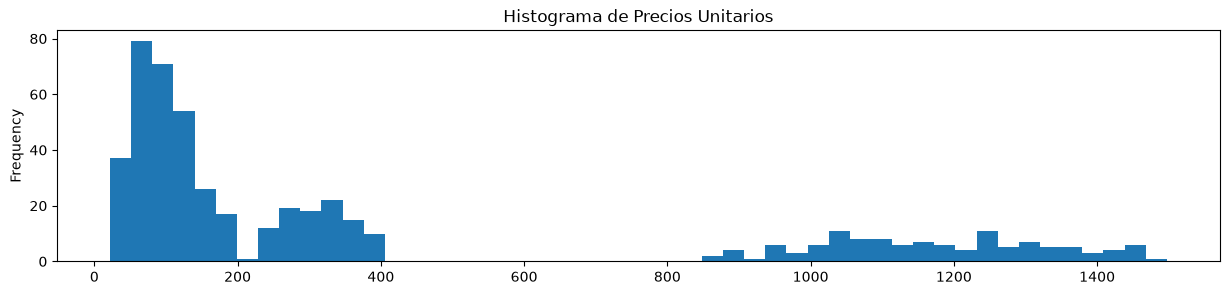

In [8]:
# Histograma: Distribución de precio unitarios
df['precio_unitario'].plot(kind='hist', bins=50, figsize=(15, 3), title='Histograma de Precios Unitarios')
plt.show()

# U5.02. Personalización con Matplotlib

## Estructura y dimensiones (figure, axes)

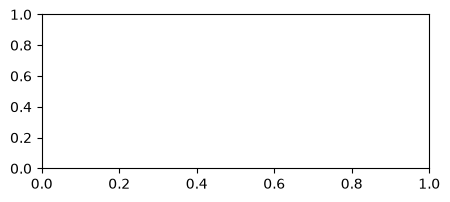

In [9]:
# Estructura básica de Matplotlib: Figure y Axes
fig, ax = plt.subplots(1, 1,figsize=(5, 2))
plt.show()

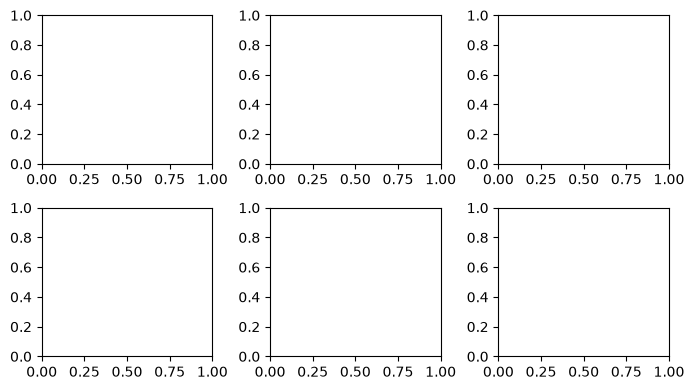

In [10]:
fig, ax = plt.subplots(2, 3,figsize=(7, 4))
plt.tight_layout()
plt.show()

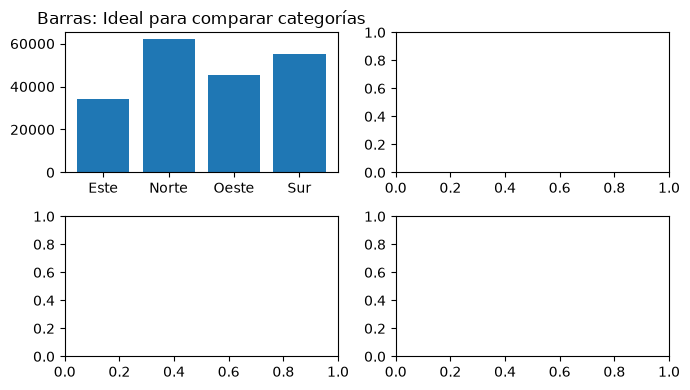

In [11]:
# Demostración: El mismo dato, diferentes gráficos
fig, axes = plt.subplots(2, 2, figsize=(7, 4))

# Comparar ventas por región
ventas_cat_desc = df.groupby('region')['precio_unitario'].sum()
plt.tight_layout()

axes[0, 0].bar(ventas_cat_desc.index, ventas_cat_desc.values)
axes[0, 0].set_title('Barras: Ideal para comparar categorías')
plt.tight_layout()
plt.show()

## Elementos esenciales y Estética y colores

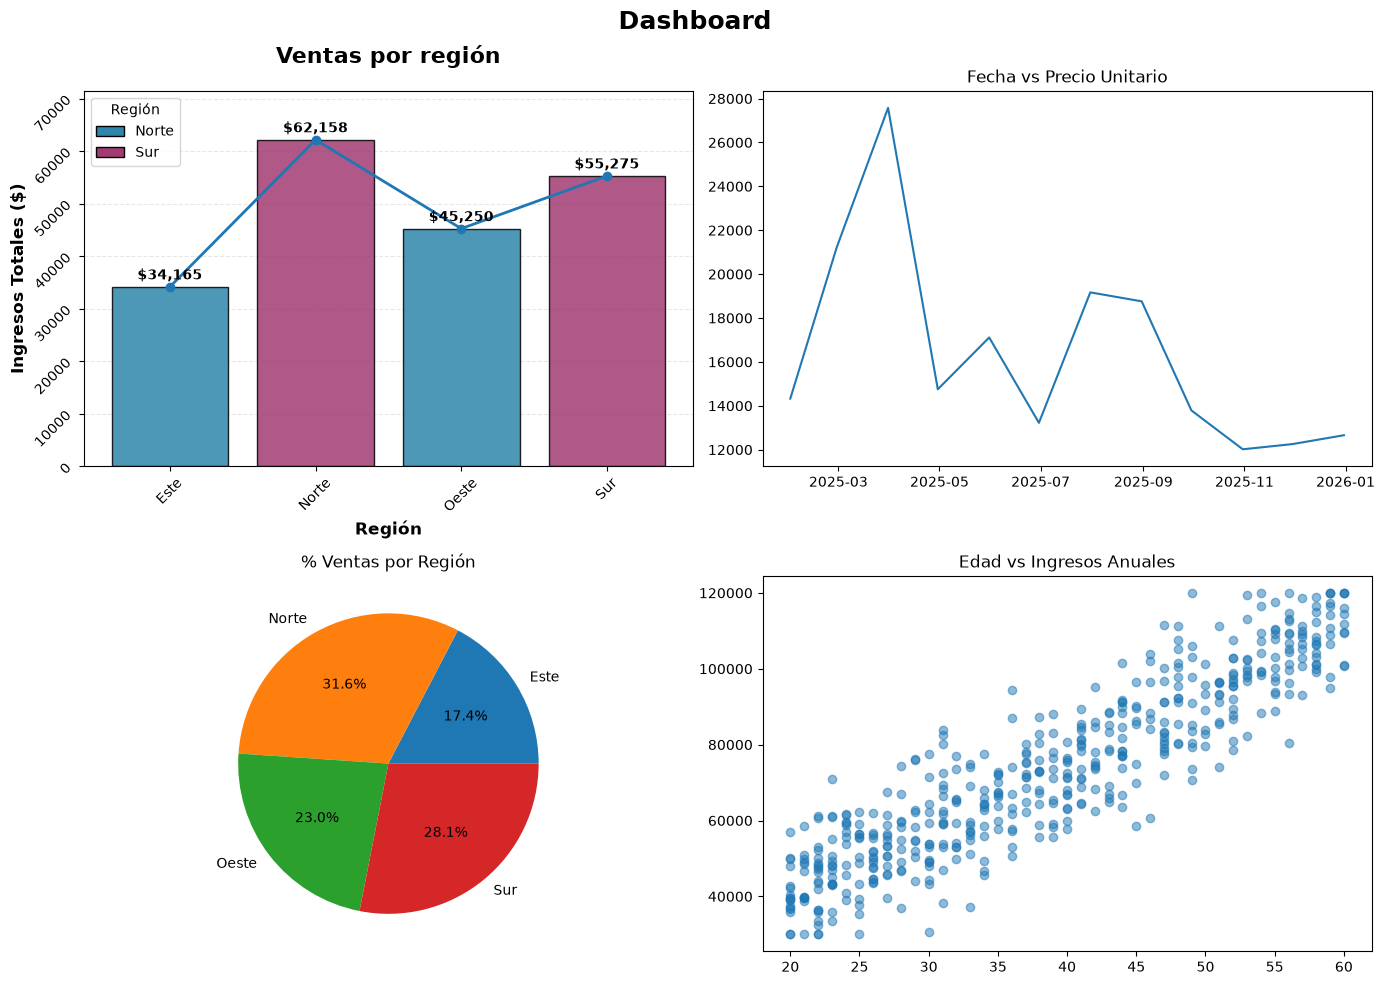

In [12]:
from matplotlib.patches import Patch
# Configuración del lienzo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

#======== TITULO GENERAL ========
fig.suptitle('Dashboard', fontsize=18, fontweight='bold', y=0.98)

# Datos de ejemplo
ventas_cat = df.groupby('region')['precio_unitario'].sum()

df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce') # Convertir a datetime
ventas_tiempo = df.groupby(pd.Grouper(key='fecha', freq='ME'))['precio_unitario'].sum().sort_index()

bars= ax1.bar(ventas_cat.index, ventas_cat.values, color=['#2E86AB', '#A23B72'], alpha=0.85, edgecolor='black')
ax1.plot(ventas_cat.index, ventas_cat.values, marker='o', linewidth=2)
ax1.set_title('Ventas por región', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Región', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
handles = [Patch(facecolor='#2E86AB', edgecolor='black', label='Norte'),
           Patch(facecolor='#A23B72', edgecolor='black', label='Sur')]
ax1.legend(handles=handles, title='Región', loc='upper left', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.bar_label(bars, fmt='${:,.0f}', padding=3, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=45)
ax1.set_axisbelow(True)
ax1.margins(y=0.15)

# Gráfico 2: Línea por fecha y precio unitario
ax2.plot(ventas_tiempo.index, ventas_tiempo.values)
ax2.set_title('Fecha vs Precio Unitario')

# Gráfico 3: Pie de % de ventas por región
ax3.pie(ventas_cat.values, labels=ventas_cat.index, autopct='%1.1f%%')
ax3.set_title('% Ventas por Región')

# Gráfico 4: Dispersión de edad vs ingresos anuales
ax4.scatter(df['edad_cliente'], df['ingresos_anuales'], alpha=0.5)
ax4.set_title('Edad vs Ingresos Anuales')

plt.tight_layout()
plt.show()


# U5.03. Seaborn para análisis exploratorio

Seaborn simplifica la creación de gráficos estadísticos.

In [13]:
# instalar la librería
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

df = pd.read_csv('u5-datos-ventas.csv')

## Distribuciones: histplot, kdeplot, boxplot, violinplot

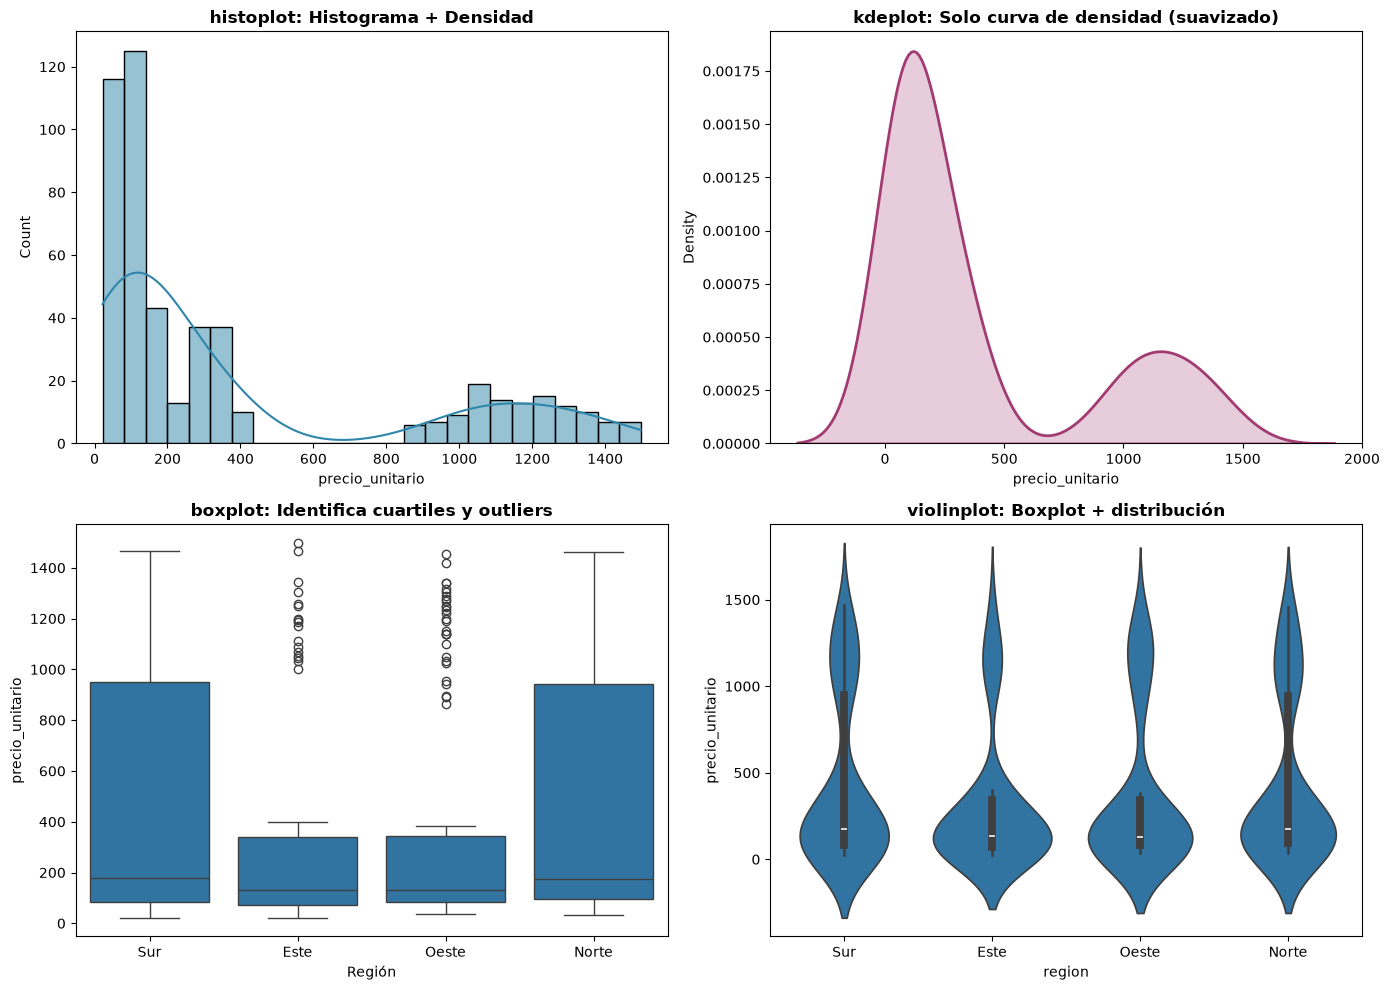

In [15]:
# DEmostración completa de distribuciones con Seaborn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1, ax2, ax3, ax4 = axes.ravel()

# 1. Histograma con KDE
sns.histplot(df['precio_unitario'], kde=True, ax=ax1, color= '#2E86AB', bins=25)
ax1.set_title('histoplot: Histograma + Densidad', fontweight='bold')

# 2. KDE Plot: Distribución suave
sns.kdeplot(df['precio_unitario'], ax=ax2, color= '#A23B72', fill=True, linewidth=2)
ax2.set_title('kdeplot: Solo curva de densidad (suavizado)', fontweight='bold')

# 3. Boxplot: Comparación de distribuciones por categoría
sns.boxplot(data=df, x='region', y='precio_unitario', ax=ax3)
ax3.set_title('boxplot: Identifica cuartiles y outliers', fontweight='bold')
ax3.set_xlabel('Región')

# 4. Violinplot: Visualización completa de distribuciones
sns.violinplot(data=df, x='region', y='precio_unitario', ax=ax4)
ax4.set_title('violinplot: Boxplot + distribución', fontweight='bold')

plt.tight_layout()
plt.show()



## Comparaciones categóricas: countplot, barplot

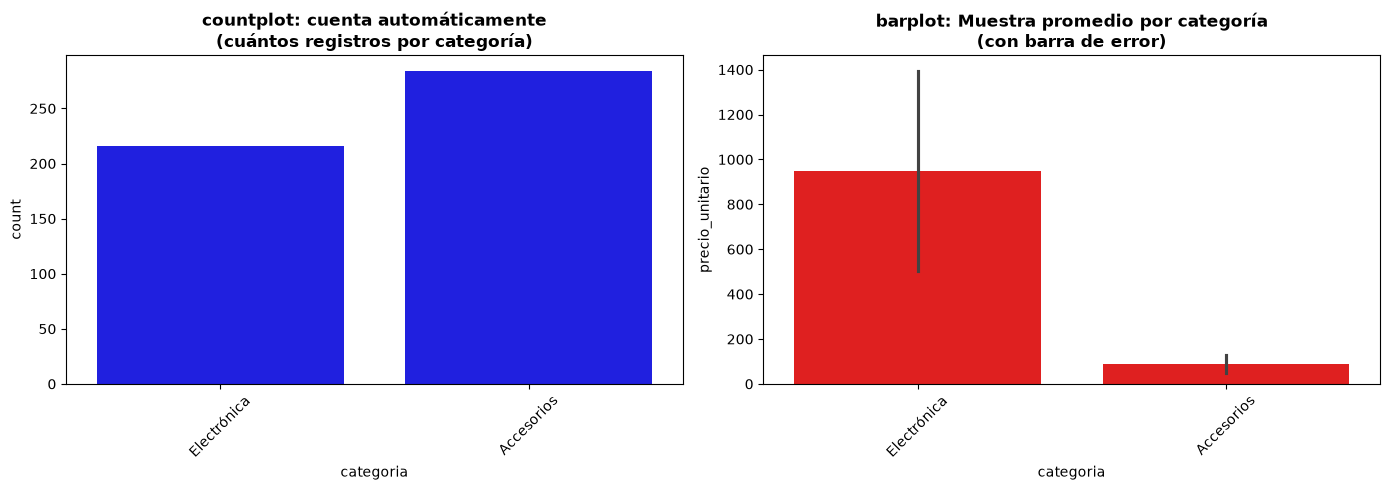

In [16]:
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax2 = axes[1]

# Countplot : Contar observaciones por categoría
sns.countplot(data=df, x='categoria', ax=ax1, color='blue')
ax1.set_title('countplot: cuenta automáticamente\n(cuántos registros por categoría)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# BARPLOT: calcula promedio u otra agregación, agregando una barra de error para cada categoría
sns.barplot(data=df, x='categoria', y='precio_unitario', ax=ax2, color='red', errorbar='sd', estimator=np.median)
ax2.set_title('barplot: Muestra promedio por categoría\n(con barra de error)', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()  


## Relaciones entre variables: scatterplot, lineplot

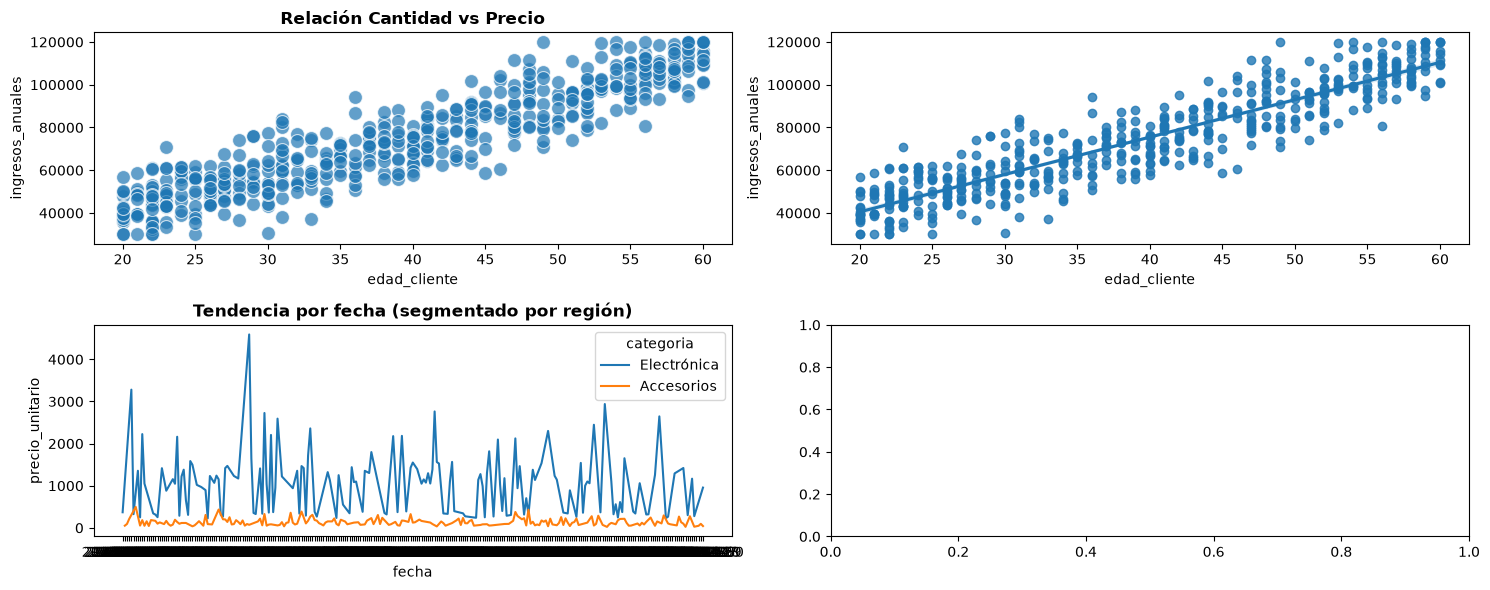

In [17]:
fig, ax = plt.subplots(2,2, figsize=(15, 6)) 
ax1, ax3, ax2, ax4= ax.ravel() 
# Scatterplot: Relación simple 
sns.scatterplot(data=df, x='edad_cliente', y='ingresos_anuales', 
	ax=ax1, s=100, alpha=0.7) 
ax1.set_title('Relación Cantidad vs Precio', fontweight='bold') 
# Regplot: Scatterplot con línea de regresión 
sns.regplot(data=df, x='edad_cliente', y='ingresos_anuales', ax=ax3) # con línea de tendencia 

# Lineplot: Evolución temporal por grupo
sns.lineplot( 
    data= df, 
    x='fecha', y='precio_unitario', 
    hue='categoria', 
    estimator='sum', 
    errorbar=None, 
    ax=ax2 
) 
ax2.set_title('Tendencia por fecha (segmentado por región)', fontweight='bold') 

plt.tight_layout()
plt.show()


# U5.04. Visualización de relaciones y correlaciones (CORRELACIONES Y HEATMAPS)

## Segmentación por categorías (hue)

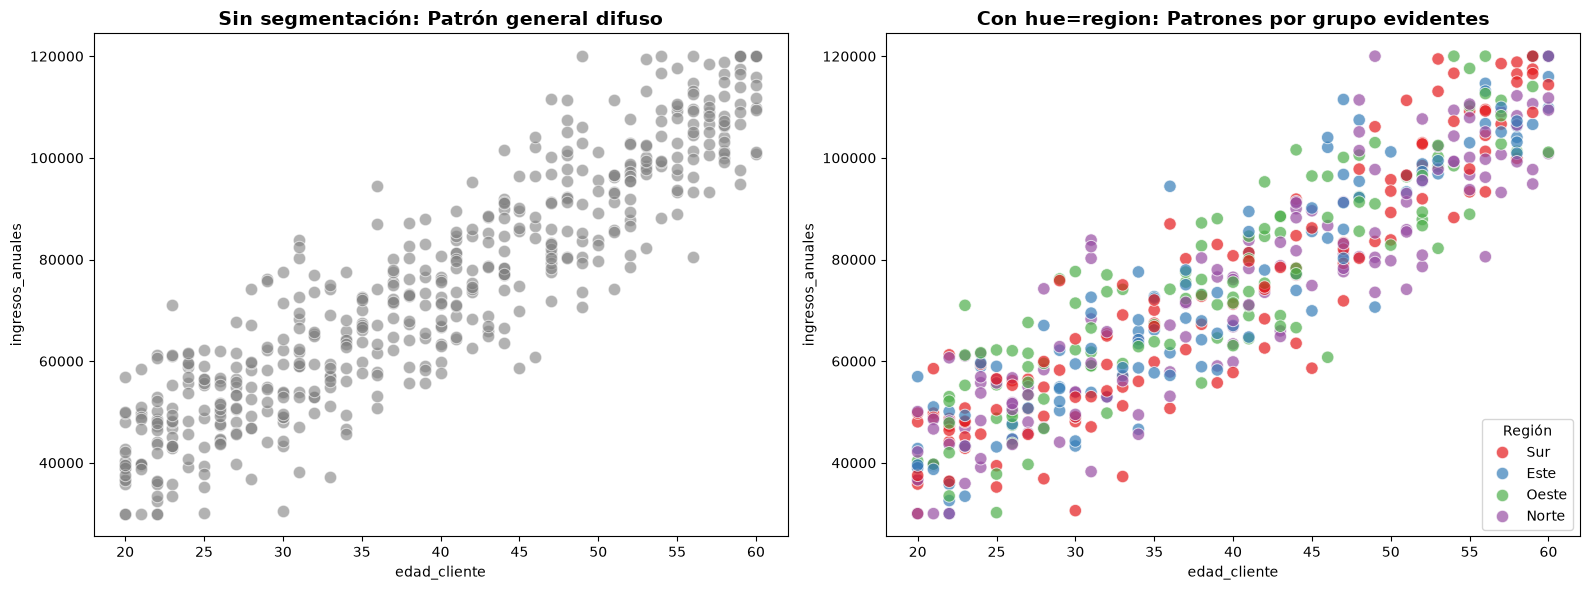

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
ax1, ax2 = axes 
# Scatterplot SIN segmentación 
sns.scatterplot(data=df, x='edad_cliente', y='ingresos_anuales', 
            ax=ax1, s=80, alpha=0.6, color='gray') 
ax1.set_title('Sin segmentación: Patrón general difuso', fontsize=14, fontweight='bold')

# Scatterplot CON segmentación por región (hue) 
sns.scatterplot(data=df, x='edad_cliente', y='ingresos_anuales', 
            hue='region', ax=ax2, s=80, alpha=0.7, palette='Set1') 
ax2.set_title('Con hue=region: Patrones por grupo evidentes', fontsize=14, fontweight='bold') 
ax2.legend(title='Región', loc='lower right') 


plt.tight_layout()
plt.show()

## Matriz de correlaciones con .corr() y heatmap

Calcular matriz de correlaciones

In [19]:
# Calcular matriz de correlaciones 
df_numeric = df[['cantidad', 'precio_unitario', 'edad_cliente', 'ingresos_anuales']] 
corr_matrix = df_numeric.corr() 
print('Matriz de Correlación:') 
print(corr_matrix.round(3))

Matriz de Correlación:
                  cantidad  precio_unitario  edad_cliente  ingresos_anuales
cantidad             1.000           -0.018         0.036             0.038
precio_unitario     -0.018            1.000        -0.025             0.001
edad_cliente         0.036           -0.025         1.000             0.912
ingresos_anuales     0.038            0.001         0.912             1.000


Visualizar como heatmap

Interpretación:
Rojo = Correlación positiva
Azul = Correlación negativa
Blanco = Sin correlación


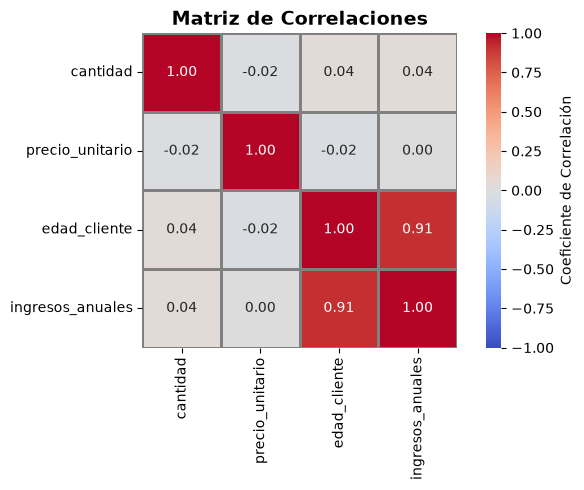

In [20]:
# Visualizar como heatmap 
fig, ax = plt.subplots(figsize=(7, 5)) 
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
		ax=ax, vmin=-1, vmax=1, square=True, 
		cbar_kws={'label': 'Coeficiente de Correlación'}, 
		linewidths=1, linecolor='gray') 
ax.set_title('Matriz de Correlaciones', fontweight='bold', fontsize=14) 

print('Interpretación:')
print('Rojo = Correlación positiva')
print('Azul = Correlación negativa')
print('Blanco = Sin correlación')

plt.tight_layout()
plt.show()

Una guía típica:

- |r| < 0.10: muy débil (casi nada)

- 0.10 – 0.30: débil

- 0.30 – 0.50: moderada

- 0.50 – 0.70: fuerte

- > 0.70: muy fuerte

**Importante: correlación ≠ causalidad**

Que dos variables estén correlacionadas no significa que una cause a la otra.
Puede haber una tercera variable explicando ambas.

## Mapa de relaciones entre variables numéricas (pairplot)

Pairplot: visualiza todas las relaciones en una matriz


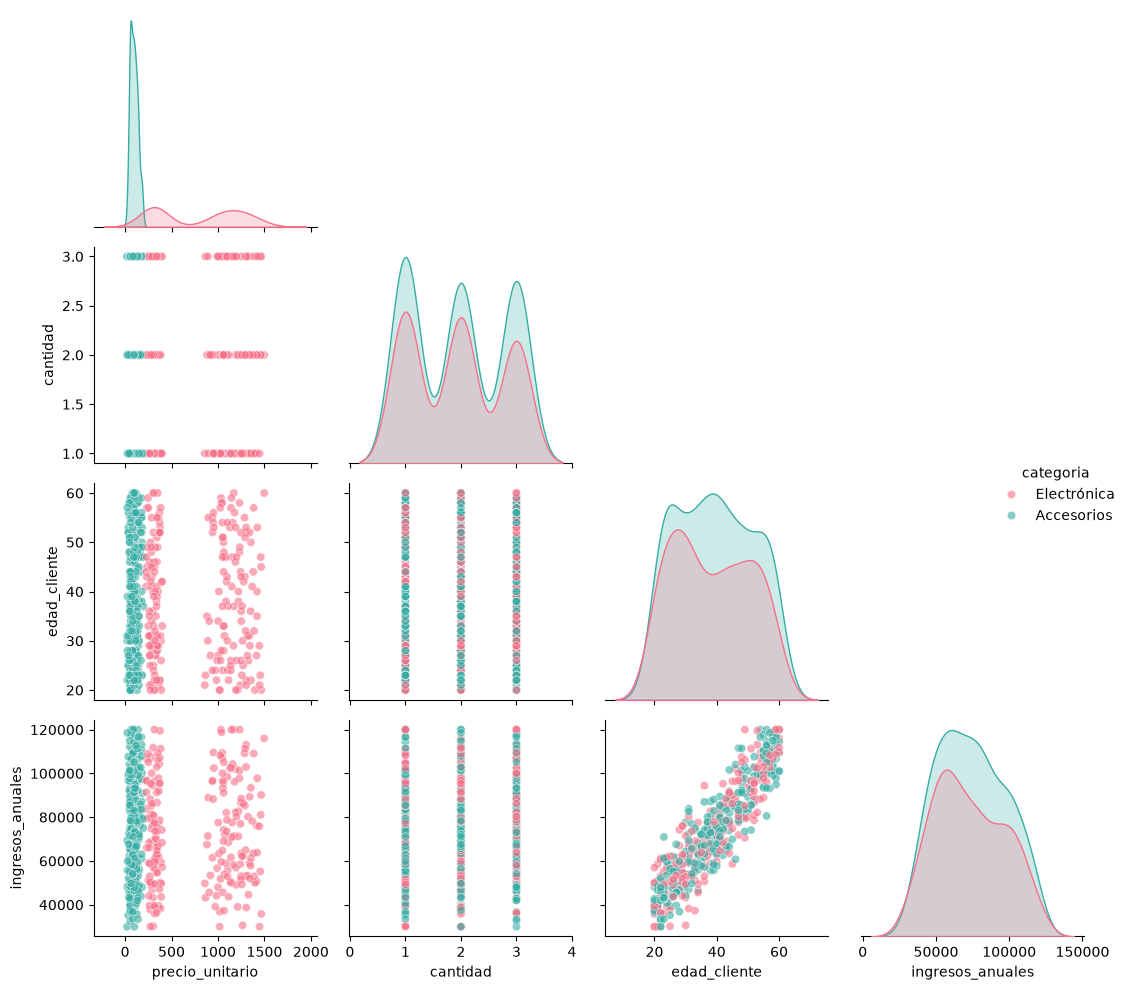

In [21]:
# Exploración rápida multivariable con pairplot 
print("Pairplot: visualiza todas las relaciones en una matriz") 
sns.pairplot(df[['precio_unitario', 'cantidad', 'edad_cliente', 'ingresos_anuales', 'categoria']], 
		hue='categoria', palette='husl', corner=True, plot_kws={'alpha': 0.6})

plt.tight_layout()
plt.show()

# U5.05. Exportar gráficos ( EXPORTAR Y PROYECTO FINAL)

## Guardar imágenes para informes

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('U5-Datos-Ventas.csv')
df['fecha'] = pd.to_datetime(df['fecha'])

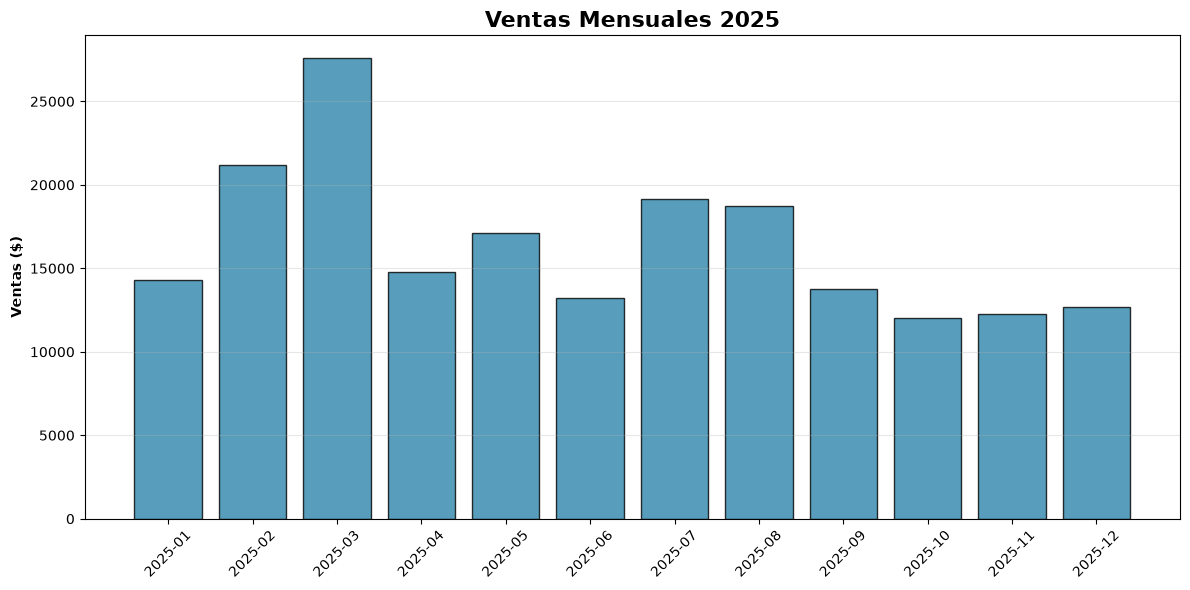

In [23]:
# Crear un gráfico de ejemplo
fig, ax = plt.subplots(figsize=(12, 6))
ventas_mes = df.groupby(df['fecha'].dt.to_period('M'))['precio_unitario'].sum()
meses = [str(m) for m in ventas_mes.index]
ax.bar(meses, ventas_mes.values, color='#2E86AB', alpha=0.8, edgecolor='black')
ax.set_title('Ventas Mensuales 2025', fontsize=16, fontweight='bold')
ax.set_ylabel('Ventas ($)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Ventas Mensuales 2025', dpi=300, bbox_inches='tight')

## Exportar Dashboard como imagen

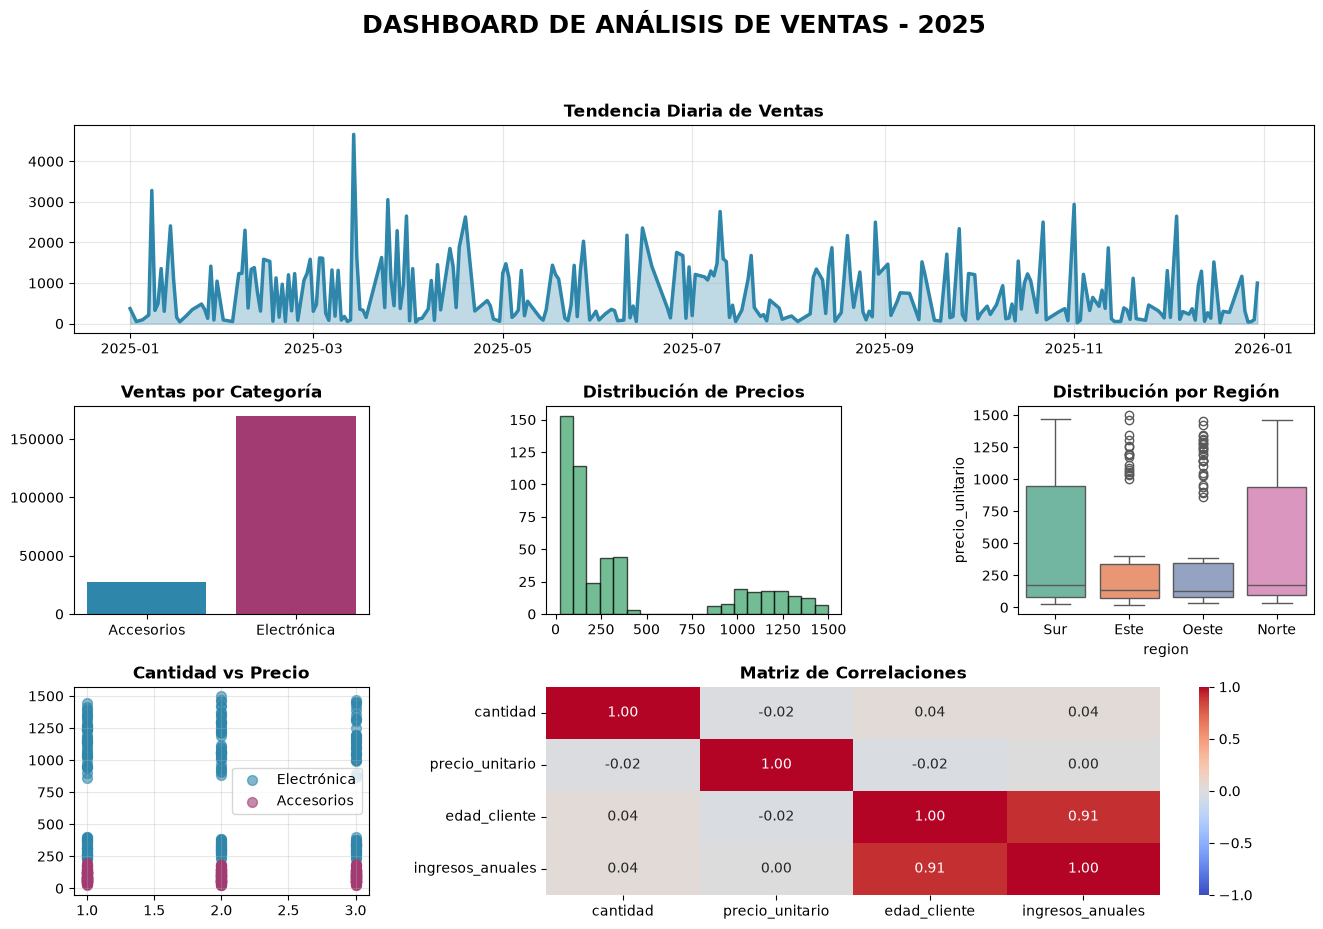

In [24]:
# Crear un dashboard completo con múltiples gráficos
fig = plt.figure(figsize=(16, 10))

# Definir una grilla para la disposición
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.6)

# 1. Tendencia temporal
ax1 = fig.add_subplot(gs[0, :])
ventas_daily = df.groupby('fecha')['precio_unitario'].sum().sort_index()
ax1.fill_between(ventas_daily.index, ventas_daily.values, alpha=0.3, color='#2E86AB')
ax1.plot(ventas_daily.index, ventas_daily.values, color='#2E86AB', linewidth=2.5)
ax1.set_title('Tendencia Diaria de Ventas', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)

# 2. Ventas por categoría
ax2 = fig.add_subplot(gs[1, 0])
ventas_cat = df.groupby('categoria')['precio_unitario'].sum()
ax2.bar(ventas_cat.index, ventas_cat.values, color=['#2E86AB', '#A23B72'])
ax2.set_title('Ventas por Categoría', fontweight='bold', fontsize=12)

# 3. Distribución de precios
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(df['precio_unitario'], bins=20, color='#38A169', edgecolor='black', alpha=0.7)
ax3.set_title('Distribución de Precios', fontweight='bold', fontsize=12)

# 4. Ventas por región
ax4 = fig.add_subplot(gs[1, 2])
sns.boxplot(
    data=df,
    x='region',
    y='precio_unitario',
    hue='region',
    palette='Set2',
    legend=False,
    ax=ax4
)
ax4.set_title('Distribución por Región', fontweight='bold', fontsize=12)

# 5. Scatter plot
ax5 = fig.add_subplot(gs[2, 0])
for categoria in df['categoria'].unique():
    datos = df[df['categoria'] == categoria]
    color = '#2E86AB' if categoria == 'Electrónica' else '#A23B72'
    ax5.scatter(datos['cantidad'], datos['precio_unitario'], 
               label=categoria, s=50, alpha=0.6, color=color)
ax5.set_title('Cantidad vs Precio', fontweight='bold', fontsize=12)
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Matriz de correlación
ax6 = fig.add_subplot(gs[2, 1:])
df_numeric = df[['cantidad', 'precio_unitario', 'edad_cliente', 'ingresos_anuales']]
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           ax=ax6, vmin=-1, vmax=1, square=False)
ax6.set_title('Matriz de Correlaciones', fontweight='bold', fontsize=12)

# Título general del dashboard
fig.suptitle('DASHBOARD DE ANÁLISIS DE VENTAS - 2025', 
            fontsize=18, fontweight='bold', y=0.995)

# # Exportar dashboard
# plt.savefig('dashboard_completo.png', dpi=300, bbox_inches='tight')
# print('✅ Dashboard creado exitosamente')

plt.show()

## Generar Dashboards Interactivos

In [25]:
# Instalar librerías dash, plotly, kaleido
# %pip install dash plotly kaleido

In [26]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Función que genera el dashboard según el filtro
def crear_dashboard_filtrable(df, producto_seleccionado='Todos'):
    
    # Filtrado de datos según selección del usuario
    if producto_seleccionado != 'Todos':
        df_filtrado = df[df['producto'] == producto_seleccionado].copy()
    else:
        df_filtrado = df.copy()
    
    # Crear estructura de subplots
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=(
            'Tendencia Diaria de Ventas', '', '',
            'Ventas por Categoría', 'Distribución de Precios', 'Distribución por Región',
            'Cantidad vs Precio', 'Matriz de Correlaciones', ''
        ),
        specs=[
            [{'colspan': 3}, None, None],
            [{}, {}, {}],
            [{'colspan': 1}, {'colspan': 2}, None]
        ],
        vertical_spacing=0.12,
        horizontal_spacing=0.10
    )
    
    # 1. Tendencia temporal
    ventas_daily = df_filtrado.groupby('fecha')['precio_unitario'].sum().sort_index()
    fig.add_trace(
        go.Scatter(
            x=ventas_daily.index, 
            y=ventas_daily.values,
            mode='lines',
            name='Ventas Diarias',
            line=dict(color='#2E86AB', width=2.5),
            fill='tozeroy',
            fillcolor='rgba(46, 134, 171, 0.3)',
            showlegend=True
        ),
        row=1, col=1
    )
    
    # 2. Ventas por categoría
    ventas_cat = df_filtrado.groupby('categoria')['precio_unitario'].sum()
    colors_cat = ['#2E86AB', '#A23B72']
    for i, (cat, valor) in enumerate(ventas_cat.items()):
        fig.add_trace(
            go.Bar(
                x=[cat], 
                y=[valor],
                name=f'{cat}',
                marker=dict(color=colors_cat[i % len(colors_cat)]),
                showlegend=True
            ),
            row=2, col=1
        )
    
    # 3. Distribución de precios
    fig.add_trace(
        go.Histogram(
            x=df_filtrado['precio_unitario'],
            nbinsx=20,
            name='Distribución Precio',
            marker=dict(color='#38A169', line=dict(color='black', width=1)),
            opacity=0.7,
            showlegend=True
        ),
        row=2, col=2
    )
    
    # 4. Boxplot por región
    for region in df_filtrado['region'].unique():
        datos_region = df_filtrado[df_filtrado['region'] == region]
        fig.add_trace(
            go.Box(
                y=datos_region['precio_unitario'],
                name=region,
                boxmean='sd',
                showlegend=True
            ),
            row=2, col=3
        )
    
    # 5. Scatter por categoría
    for categoria in df_filtrado['categoria'].unique():
        datos = df_filtrado[df_filtrado['categoria'] == categoria]
        color = '#2E86AB' if categoria == 'Electrónica' else '#A23B72'
        fig.add_trace(
            go.Scatter(
                x=datos['edad_cliente'],
                y=datos['ingresos_anuales'],
                mode='markers',
                name=f'{categoria} (scatter)',
                marker=dict(color=color, size=8, opacity=0.6),
                showlegend=True
            ),
            row=3, col=1
        )
    
    # 6. Heatmap de correlaciones
    df_numeric = df_filtrado[['cantidad', 'precio_unitario', 'edad_cliente', 'ingresos_anuales']]
    corr_matrix = df_numeric.corr()
    fig.add_trace(
        go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='RdBu',
            zmid=0,
            zmin=-1,
            zmax=1,
            text=corr_matrix.values,
            texttemplate='%{text:.2f}',
            showscale=True,
            showlegend=False,
            colorbar=dict(
                title="Corr",
                x=1,          # posición horizontal (0 a 1, “paper coords”)
                y=0.15,           # posición vertical (0 a 1)
                len=0.28,         # alto de la barra (0 a 1)
                thickness=12      # grosor en px
            )
        ),
        row=3, col=2
    )
    
    # Configuración de layout y leyenda interactiva
    fig.update_layout(
        height=1000,
        showlegend=True,
        template='plotly_white',
        title={
            'text': f'Dashboard de Análisis de Ventas - {producto_seleccionado}',
            'x': 0.5,
            'xanchor': 'center', 
            'font': {'size': 20, 'family': 'Arial Black', 'color': '#2C3E50'}
        },
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1.10,
            xanchor="left",
            x=1,
            bgcolor="rgba(255,255,255,0.8)",
            bordercolor="Black",
            borderwidth=1,
            font=dict(size=11),
            itemclick="toggle",
            itemdoubleclick="toggleothers"
        ),
        hovermode='closest'
    )
    
    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
    
    return fig

# Crear instancia de la aplicación Dash
app = Dash(__name__)

app.layout = html.Div([
    html.H1('📊 DASHBOARD DE VENTAS 2025', 
            style={'textAlign': 'center', 'color': '#2C3E50', 'marginBottom': '20px'}),
    
    # Segmentador desplegable
    html.Div([
        html.Label('🔍 Filtrar por Producto:', 
                  style={'fontWeight': 'bold', 'fontSize': '16px', 'marginRight': '15px'}),
        dcc.Dropdown(
            id='producto-dropdown',
            options=[{'label': prod, 'value': prod} 
                    for prod in ['Todos'] + sorted(df['producto'].unique().tolist())],
            value='Todos',
            clearable=False,
            style={'width': '250px'}
        )
    ], style={'padding': '20px', 'display': 'flex', 'alignItems': 'center', 
              'justifyContent': 'center', 'backgroundColor': '#ECF0F1'}),
    
    # Componente de gráfico que se actualiza dinámicamente
    dcc.Graph(id='dashboard-graph', style={'height': '1000px'})
])

# Callback que conecta el dropdown con el gráfico
@app.callback(
    Output('dashboard-graph', 'figure'),
    Input('producto-dropdown', 'value')
)
def actualizar_dashboard(producto_seleccionado):
    return crear_dashboard_filtrable(df, producto_seleccionado)

# Opción 1: Inline (se muestra dentro del notebook)
app.run(jupyter_mode='inline', port=8050)

# Opción 2: External (muestra un link para abrir en navegador)
# app.run(jupyter_mode='external', port=8050)

# Opción 3: Tab (abre automáticamente en nueva pestaña del navegador)
# app.run(jupyter_mode='tab', port=8050)

# Opción 4: JupyterLab (pestaña separada dentro de JupyterLab)
# app.run(jupyter_mode='jupyterlab', port=8050)

# print('🚀 App corriendo en: http://127.0.0.1:8050/')


# # Generar figura para exportación
# fig = crear_dashboard_filtrable(df, 'Todos')

# # Exportar como HTML standalone
# fig.write_html('dashboard_ventas.html')
# print('✅ Dashboard exportado como: dashboard_ventas.html')

# # Exportar múltiples versiones (una por producto)
# productos = ['Todos'] + sorted(df['producto'].unique().tolist())

# for producto in productos:
#     fig_producto = crear_dashboard_filtrable(df, producto)
#     nombre_archivo = f"dashboard_{producto.replace(' ', '_').replace('/', '-')}.html"
#     fig_producto.write_html(nombre_archivo)
#     print(f'✅ Exportado: {nombre_archivo}')

# print(f'\n📁 Total: {len(productos)} dashboards HTML generados')

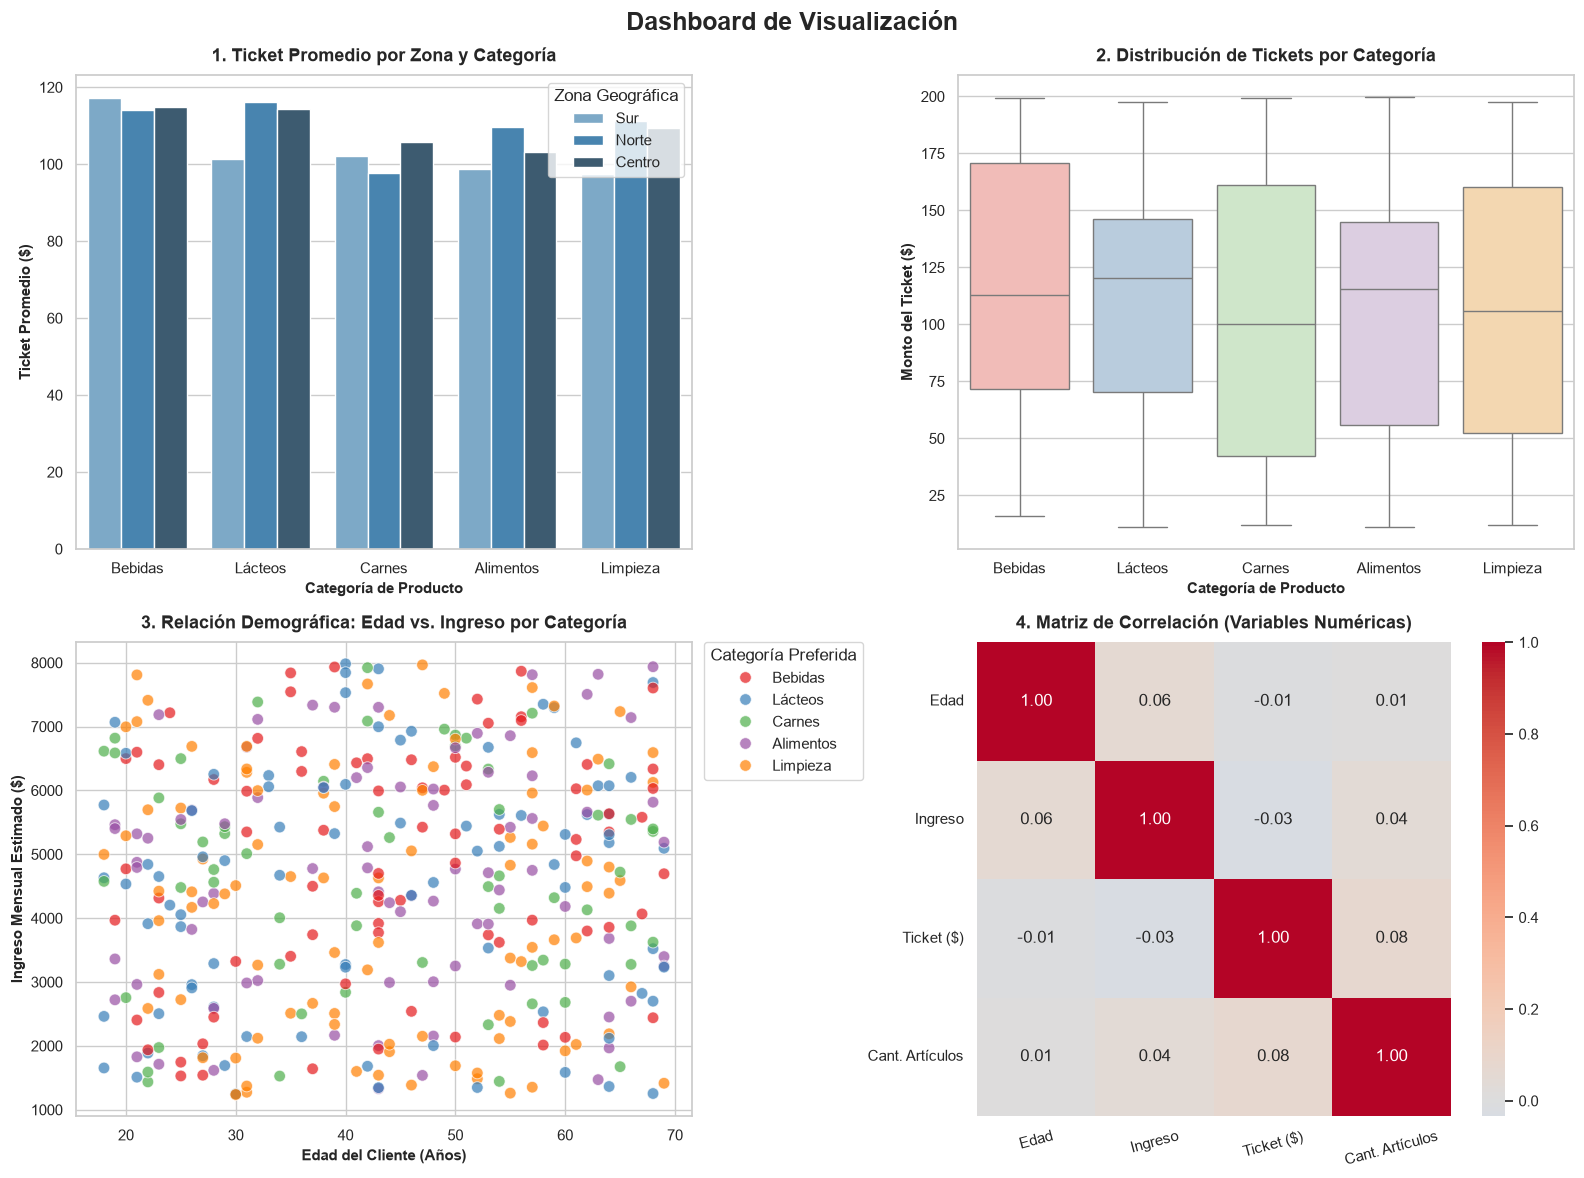

In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# PASO 1: Cargar los datos
# ==============================================================================
# Si vas a usar el archivo de tu carpeta raw/ o processed/, usa la ruta:
# ruta = Path("data/raw/ventas_2024_03_01.csv")
# df = pd.read_csv(ruta)

# (Dejo estos datos de ejemplo para que puedas ejecutar el código directamente y probarlo)
np.random.seed(42)
n = 400
zonas = ['Norte', 'Centro', 'Sur']
categorias = ['Alimentos', 'Lácteos', 'Carnes', 'Bebidas', 'Limpieza']

df = pd.DataFrame({
    'zona': np.random.choice(zonas, n),
    'categoria': np.random.choice(categorias, n),
    'edad': np.random.randint(18, 70, n),
    'ingreso': np.random.randint(1200, 8000, n),
    'monto_ticket': np.random.uniform(10, 200, n),
    'cantidad_articulos': np.random.randint(1, 15, n),
})

# ==============================================================================
# PASO 2: Configurar la figura de 2x2
# ==============================================================================
# Elegimos un tema visual limpio con cuadrícula suave
sns.set_theme(style='whitegrid')

# Creamos la figura principal y los 4 cuadrantes (2 filas, 2 columnas)
# El tamaño (16, 12) es bastante amplio para que no se apriete nada
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Título general para todo el Dashboard
fig.suptitle(
    'Dashboard de Visualización',
    fontsize=18,
    fontweight='bold',
    y=0.98,
)

# ==============================================================================
# SUBPLOT 1: Barras agrupadas (Ticket promedio por zona y categoría)
# Ubicación: Arriba a la izquierda [0, 0]
# ==============================================================================
sns.barplot(
    data=df,
    x='categoria',
    y='monto_ticket',
    hue='zona',
    errorbar=None,  # Para mostrar solo la barra limpia con el promedio
    palette='Blues_d',
    ax=axes[0, 0],
)

axes[0, 0].set_title(
    '1. Ticket Promedio por Zona y Categoría',
    fontsize=13,
    fontweight='bold',
    pad=10,
)
axes[0, 0].set_xlabel('Categoría de Producto', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Ticket Promedio ($)', fontsize=11, fontweight='bold')
axes[0, 0].legend(title='Zona Geográfica', loc='upper right')

# ==============================================================================
# SUBPLOT 2: Boxplot (Distribución de tickets por categoría)
# Ubicación: Arriba a la derecha [0, 1]
# ==============================================================================
sns.boxplot(
    data=df,
    x='categoria',
    y='monto_ticket',
    hue='categoria',  # Le pasamos hue para evitar avisos de Seaborn
    legend=False,
    palette='Pastel1',
    ax=axes[0, 1],
)

axes[0, 1].set_title(
    '2. Distribución de Tickets por Categoría',
    fontsize=13,
    fontweight='bold',
    pad=10,
)
axes[0, 1].set_xlabel('Categoría de Producto', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Monto del Ticket ($)', fontsize=11, fontweight='bold')

# ==============================================================================
# SUBPLOT 3: Scatter plot (Relación demográfica: Edad vs. Ingreso)
# Ubicación: Abajo a la izquierda [1, 0]
# ==============================================================================
sns.scatterplot(
    data=df,
    x='edad',
    y='ingreso',
    hue='categoria',
    alpha=0.7,  # Le damos transparencia para notar si hay puntos encimados
    s=70,  # Tamaño de los puntitos
    palette='Set1',
    ax=axes[1, 0],
)

axes[1, 0].set_title(
    '3. Relación Demográfica: Edad vs. Ingreso por Categoría',
    fontsize=13,
    fontweight='bold',
    pad=10,
)
axes[1, 0].set_xlabel('Edad del Cliente (Años)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel(
    'Ingreso Mensual Estimado ($)', fontsize=11, fontweight='bold'
)
# Ponemos la leyenda al ladito para que no tape los puntos
axes[1, 0].legend(
    title='Categoría Preferida',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
)

# ==============================================================================
# SUBPLOT 4: Heatmap (Matriz de correlación entre variables numéricas)
# Ubicación: Abajo a la derecha [1, 1]
# ==============================================================================
# Filtramos solo las columnas numéricas para sacar la correlación
cols_numericas = ['edad', 'ingreso', 'monto_ticket', 'cantidad_articulos']
matriz_corr = df[cols_numericas].corr()

sns.heatmap(
    matriz_corr,
    annot=True,  # Para que se vean los números dentro de los cuadritos
    fmt='.2f',  # Redondeado a dos decimales
    cmap='coolwarm',  # Azul para negativos, rojo para positivos
    center=0,
    cbar=True,
    ax=axes[1, 1],
    square=True,  # Cuadros simétricos
)

axes[1, 1].set_title(
    '4. Matriz de Correlación (Variables Numéricas)',
    fontsize=13,
    fontweight='bold',
    pad=10,
)
# Mejoramos los nombres de los ejes para que se lean prolijos
axes[1, 1].set_xticklabels(
    ['Edad', 'Ingreso', 'Ticket ($)', 'Cant. Artículos'], rotation=15
)
axes[1, 1].set_yticklabels(
    ['Edad', 'Ingreso', 'Ticket ($)', 'Cant. Artículos'], rotation=0
)

# ==============================================================================
# PASO 3: Ajustes finales y visualización
# ==============================================================================
# tight_layout evita que los títulos o textos se solapen entre sí
plt.tight_layout()
# Mostramos el dashboard en pantalla
plt.show()

In [30]:
# ==============================================================================
# PASO DE EXPORTACIÓN PROFESIONAL
# (Recuerda colocar esto ANTES de escribir plt.show())
# ==============================================================================

# 1. Exportación en PNG de Alta Resolución (300 DPI)
# Óptimo para correo electrónico, presentaciones de PowerPoint o ver en tablets/PCs
plt.savefig(
    'dashboard_ejecutivo_mercaplus_300dpi.png',
    dpi=300,  # Multiplica la densidad de píxeles para que no se vea borroso
    bbox_inches='tight',  # Ajusta los bordes para que no se corte ningún texto
    facecolor='white',  # Asegura que el fondo sea blanco y no transparente
)

# 2. Exportación en PDF Vectorial
# Ideal para que Patricia Mendoza lo imprima para la reunión de directorio
plt.savefig(
    'dashboard_ejecutivo_mercaplus_vectorial.pdf',
    bbox_inches='tight',  # Mantiene las etiquetas completas y prolijas
)

print('¡Archivos exportados exitosamente!')

# Ahora sí, si quieres verlo en pantalla:
plt.show()

¡Archivos exportados exitosamente!


<Figure size 640x480 with 0 Axes>

¡Listo! Archivos exportados con éxito sin páginas en blanco.


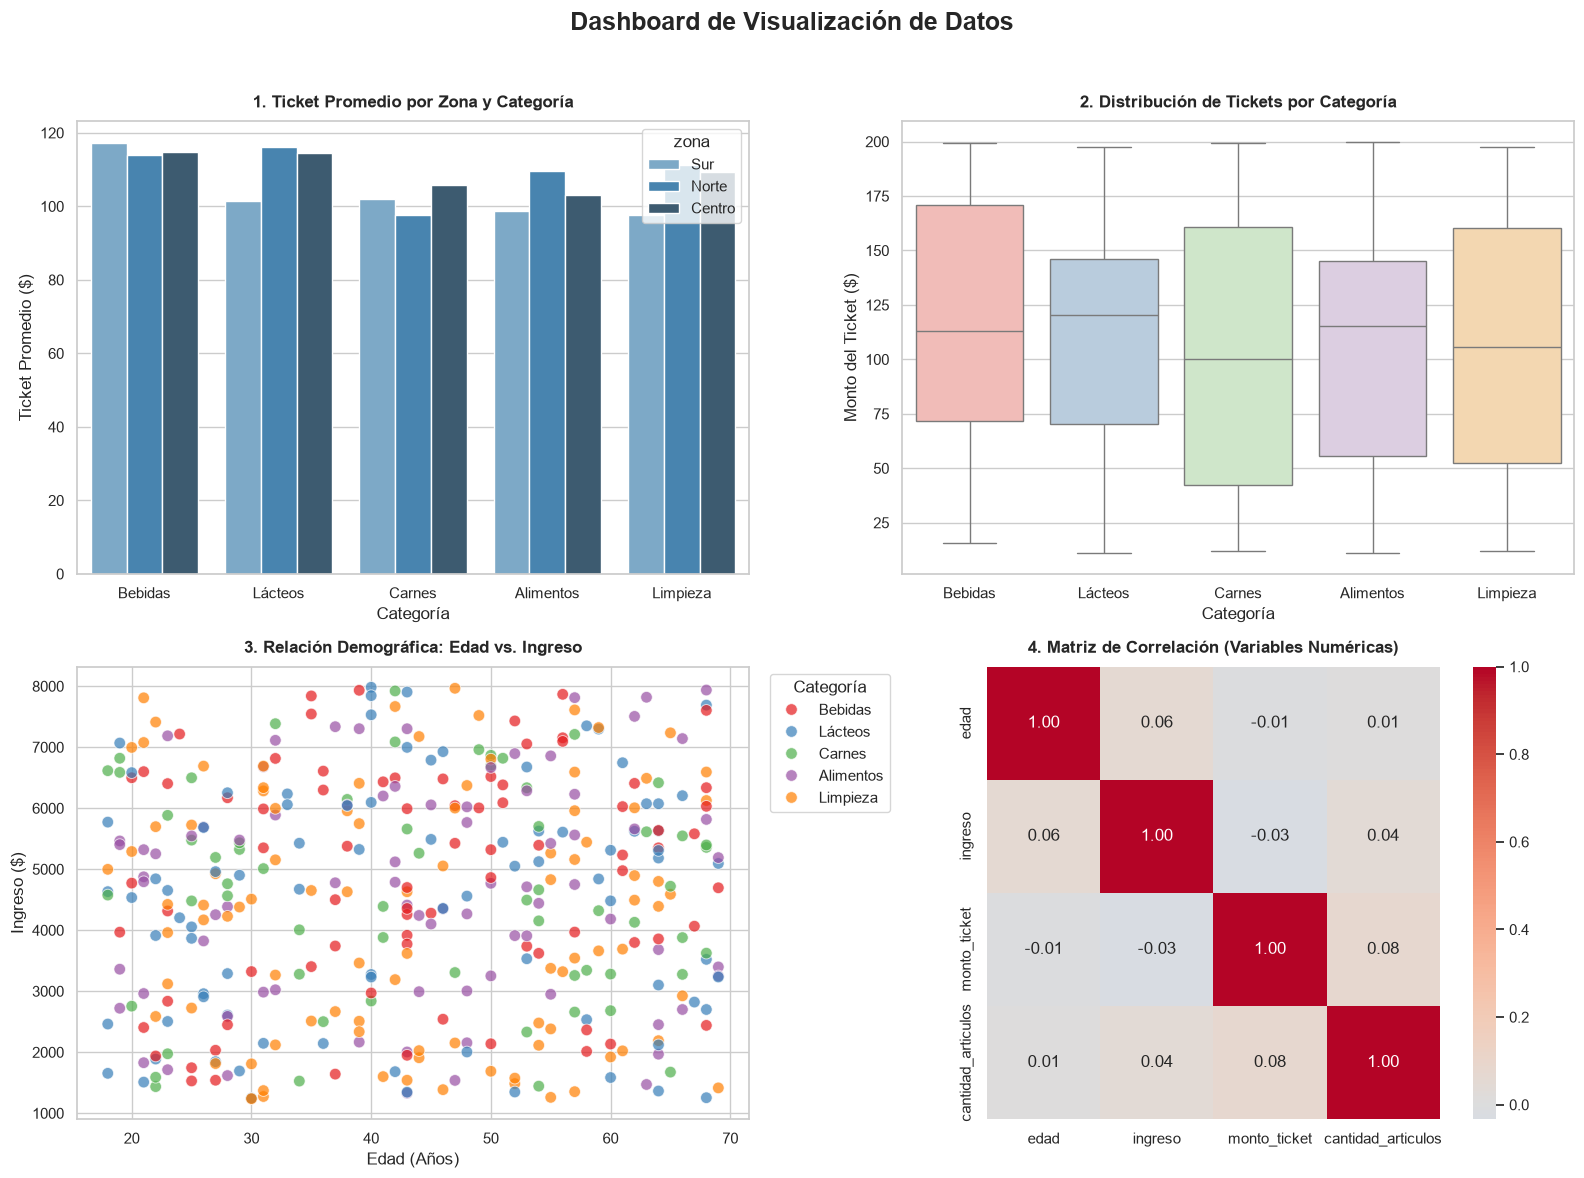

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. DATOS (Simulados para la prueba)
np.random.seed(42)
n = 400
zonas = ['Norte', 'Centro', 'Sur']
categorias = ['Alimentos', 'Lácteos', 'Carnes', 'Bebidas', 'Limpieza']

df = pd.DataFrame({
    'zona': np.random.choice(zonas, n),
    'categoria': np.random.choice(categorias, n),
    'edad': np.random.randint(18, 70, n),
    'ingreso': np.random.randint(1200, 8000, n),
    'monto_ticket': np.random.uniform(10, 200, n),
    'cantidad_articulos': np.random.randint(1, 15, n),
})

# 2. CREAMOS LA FIGURA (Guardada en la variable 'fig')
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Dashboard de Visualización de Datos',
    fontsize=18,
    fontweight='bold',
    y=0.98,
)

# Subplot 1: Barras agrupadas
sns.barplot(
    data=df,
    x='categoria',
    y='monto_ticket',
    hue='zona',
    errorbar=None,
    palette='Blues_d',
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    '1. Ticket Promedio por Zona y Categoría',
    fontweight='bold',
    pad=10,
)
axes[0, 0].set_xlabel('Categoría')
axes[0, 0].set_ylabel('Ticket Promedio ($)')

# Subplot 2: Boxplot
sns.boxplot(
    data=df,
    x='categoria',
    y='monto_ticket',
    hue='categoria',
    legend=False,
    palette='Pastel1',
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    '2. Distribución de Tickets por Categoría',
    fontweight='bold',
    pad=10,
)
axes[0, 1].set_xlabel('Categoría')
axes[0, 1].set_ylabel('Monto del Ticket ($)')

# Subplot 3: Scatter plot
sns.scatterplot(
    data=df,
    x='edad',
    y='ingreso',
    hue='categoria',
    alpha=0.7,
    s=70,
    palette='Set1',
    ax=axes[1, 0],
)
axes[1, 0].set_title(
    '3. Relación Demográfica: Edad vs. Ingreso', fontweight='bold', pad=10
)
axes[1, 0].set_xlabel('Edad (Años)')
axes[1, 0].set_ylabel('Ingreso ($)')
axes[1, 0].legend(
    title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left'
)

# Subplot 4: Heatmap
cols_num = ['edad', 'ingreso', 'monto_ticket', 'cantidad_articulos']
matriz_corr = df[cols_num].corr()
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    cbar=True,
    ax=axes[1, 1],
    square=True,
)
axes[1, 1].set_title(
    '4. Matriz de Correlación (Variables Numéricas)', fontweight='bold', pad=10
)

# Ajuste de bordes
plt.tight_layout(rect=[0, 0, 1, 0.96])

# ==============================================================================
# 3. EXPORTAR DIRECTAMENTE DESDE LA VARIABLE 'fig' (¡ANTES de plt.show()!)
# ==============================================================================
fig.savefig(
    'dashboard_visualizacion_300dpi.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
fig.savefig('dashboard_visualizacion_vectorial.pdf', bbox_inches='tight')

print(
    '¡Listo! Archivos exportados con éxito sin páginas en blanco.'
)

# 4. Al final de TODO, si quieres ver la ventana emergente:
plt.show()